# 05 - Train a perception encoder and test imagery transfer

Companion documents: [`docs/guides/brain_encoding_workflow.md`](../docs/guides/brain_encoding_workflow.md) and [`docs/results/brain_encoding_results.md`](../docs/results/brain_encoding_results.md).

This notebook orchestrates the leakage-safe baseline: core NSD image → frozen multilayer ViT features → PCA → voxelwise ridge → held-out core-NSD validation → frozen evaluation on NSD-Imagery vision and imagery.

**Scientific guardrail:** NSD-Imagery is never used to select layers, PCA dimension, ridge penalty, voxels, or training duration. Repeated core-NSD presentations are averaged before image-level splitting.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
import torch
from IPython.display import Image

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
DATA_ROOT = Path(os.environ.get('NSD_DATA_ROOT', REPO_ROOT / 'data' / 'nsd')).expanduser().resolve()
STIMULI_PATH = Path(os.environ.get(
    'NSD_STIMULI',
    DATA_ROOT / 'nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5',
)).expanduser().resolve()
SUBJECT = 1
MODEL_ID = 'facebook/dinov2-small'
METHOD = 'DINOv2_PyramidRidge'
WORK = REPO_ROOT / 'outputs' / '06_core_nsd_encoder' / f'subj{SUBJECT:02d}' / 'dinov2_small'
WORK.mkdir(parents=True, exist_ok=True)

print('Python:', sys.executable)
print('Data root:', DATA_ROOT)
print('Stimulus HDF5:', STIMULI_PATH)
print('Stimulus HDF5 exists:', STIMULI_PATH.is_file())
print('Work directory:', WORK)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Python: /srv/conda/envs/nsdimagery/bin/python
Data root: /home/jovyan/NHprojectNSDimagery/data/nsd
Stimulus HDF5: /home/jovyan/NHprojectNSDimagery/data/nsd/nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5
Stimulus HDF5 exists: False
Work directory: /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small
CUDA: True
Tesla T4


## 1. Estimate and download core NSD

Run the estimate before downloading. A five-session download is useful only as a pipeline smoke test; use all completed sessions for scientific results. Data must live on persistent storage.

In [2]:
RUN_ESTIMATE = False
RUN_DOWNLOAD = False
RUN_STIMULI_ONLY = False  # recover HDF5 after a --skip-stimuli download
download_command = [
    'bash', str(REPO_ROOT / 'scripts' / 'download_core_nsd_encoder_mvp.sh'),
    '--subject', f'{SUBJECT:02d}',
    '--sessions', 'all',
    '--dest', str(DATA_ROOT),
]
print(' '.join(download_command + ['--estimate']))
if RUN_ESTIMATE:
    subprocess.run(download_command + ['--estimate'], check=True)
if RUN_DOWNLOAD:
    subprocess.run(download_command, check=True)
if RUN_STIMULI_ONLY:
    subprocess.run(download_command + ['--stimuli-only'], check=True)

bash /home/jovyan/NHprojectNSDimagery/scripts/download_core_nsd_encoder_mvp.sh --subject 01 --sessions all --dest /home/jovyan/NHprojectNSDimagery/data/nsd --estimate


## 2. Prepare unique-image beta targets

The preparation reads one beta session at a time, masks `nsdgeneral`, Z-scores every voxel within session, averages repeated presentations of each image, and reserves the shared 1,000 NSD images for the final perception test.

In [3]:
RUN_PREPARE = False
prepare_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'prepare_core_nsd_encoder_data.py'),
    '--data-root', str(DATA_ROOT),
    '--subject', str(SUBJECT),
    '--output-dir', str(WORK),
    '--split-mode', 'shared1000',
]
print(' '.join(prepare_command))
if RUN_PREPARE:
    subprocess.run(prepare_command, check=True)

/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/prepare_core_nsd_encoder_data.py --data-root /home/jovyan/NHprojectNSDimagery/data/nsd --subject 1 --output-dir /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small --split-mode shared1000


In [4]:
core_manifest_path = WORK / f'core_subj{SUBJECT:02d}_manifest.csv'
if core_manifest_path.is_file():
    core_manifest = pd.read_csv(core_manifest_path)
    display(core_manifest.groupby('split').agg(
        unique_images=('row_id', 'size'),
        mean_repeats=('n_repeats', 'mean'),
    ))
else:
    print('Run the preparation step first.')

,unique_images,mean_repeats
split,,
test,1000,3.0
train,8100,3.0
validation,900,3.0


## 3. Cache frozen multilayer image features

The default extracts DINOv2 hidden states 3, 6, 9, and 12. CLS plus 1×1 and 2×2 pooled patch features preserve both semantic and coarse spatial information. The pretrained backbone remains frozen.

In [5]:
RUN_CORE_FEATURES = False
core_features_path = WORK / 'core_features.npz'
feature_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'extract_image_features.py'),
    '--manifest', str(core_manifest_path),
    '--nsd-stimuli', str(STIMULI_PATH),
    '--model-id', MODEL_ID,
    '--layers', '3,6,9,12',
    '--pyramid-levels', '1,2',
    '--batch-size', '64',
    '--device', 'auto',
    '--output', str(core_features_path),
]
print(' '.join(feature_command))
if RUN_CORE_FEATURES:
    if not STIMULI_PATH.is_file():
        raise FileNotFoundError(
            f'Missing stimulus bank: {STIMULI_PATH}\n'
            'Set RUN_STIMULI_ONLY=True or set NSD_STIMULI to its actual path.'
        )
    subprocess.run(feature_command, check=True)

/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/extract_image_features.py --manifest /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_subj01_manifest.csv --nsd-stimuli /home/jovyan/NHprojectNSDimagery/data/nsd/nsddata_stimuli/stimuli/nsd/nsd_stimuli.hdf5 --model-id facebook/dinov2-small --layers 3,6,9,12 --pyramid-levels 1,2 --batch-size 64 --device auto --output /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_features.npz


## 4. Select ridge penalty and test held-out perception

PCA and alpha selection see only the core-NSD train/validation identities. The selected model is refit on train+validation and evaluated once on the shared-1000 test images. A meaningful imagery analysis requires positive held-out perception predictivity.

In [6]:
RUN_FIT = False
encoder_path = WORK / 'encoder_model.npz'
summary_path = WORK / 'core_test_summary.json'
fit_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'fit_ridge_encoder.py'),
    '--manifest', str(core_manifest_path),
    '--betas', str(WORK / f'core_subj{SUBJECT:02d}_betas.npy'),
    '--coordinates', str(WORK / f'core_subj{SUBJECT:02d}_coordinates.npy'),
    '--voxel-regions', str(WORK / f'core_subj{SUBJECT:02d}_voxel_regions.csv'),
    '--features', str(core_features_path),
    '--pca-components', '512',
    '--alphas', '0.1,1,10,100,1000',
    '--device', 'auto',
    '--method', METHOD,
    '--output-model', str(encoder_path),
    '--output-summary', str(summary_path),
    '--output-voxel-metrics', str(WORK / 'core_test_voxels.csv'),
]
print(' '.join(fit_command))
if RUN_FIT:
    subprocess.run(fit_command, check=True)
if summary_path.is_file():
    display(pd.json_normalize(json.loads(summary_path.read_text())))

/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/fit_ridge_encoder.py --manifest /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_subj01_manifest.csv --betas /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_subj01_betas.npy --coordinates /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_subj01_coordinates.npy --voxel-regions /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_subj01_voxel_regions.csv --features /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_features.npz --pca-components 512 --alphas 0.1,1,10,100,1000 --device auto --method DINOv2_PyramidRidge --output-model /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/encoder_model.npz --output-summary /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_test

,method,selected_alpha,pca_components,n_train_images,n_validation_images,n_final_train_images,n_test_images,n_voxels,target_space,test_mean_voxel_correlation,...,test_by_region.early_visual.median_voxel_correlation,test_by_region.early_visual.mean_voxel_r2,test_by_region.higher_visual.n_voxels,test_by_region.higher_visual.mean_voxel_correlation,test_by_region.higher_visual.median_voxel_correlation,test_by_region.higher_visual.mean_voxel_r2,test_by_region.visual_cortex.n_voxels,test_by_region.visual_cortex.mean_voxel_correlation,test_by_region.visual_cortex.median_voxel_correlation,test_by_region.visual_cortex.mean_voxel_r2
0,DINOv2_PyramidRidge,1000.0,512,8100,900,9000,1000,15724,per-voxel standardized core-NSD betas,0.351581,...,0.396695,0.170195,11067,0.336406,0.327999,0.133602,15724,0.351581,0.349395,0.14444


## 5. Extract A/B target features

These are ground-truth targets, so this stage isolates encoder transfer without reconstruction error. Use exactly the same feature configuration as training.

In [7]:
RUN_TARGET_MANIFEST = False
RUN_TARGET_FEATURES = False
target_manifest_path = WORK / 'nsdimagery_AB_manifest.csv'
target_features_path = WORK / 'nsdimagery_AB_features.npz'
target_manifest_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'make_nsdimagery_image_manifest.py'),
    '--data-root', str(DATA_ROOT),
    '--output', str(target_manifest_path),
]
target_feature_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'extract_image_features.py'),
    '--manifest', str(target_manifest_path),
    '--model-id', MODEL_ID,
    '--layers', '3,6,9,12',
    '--pyramid-levels', '1,2',
    '--device', 'auto',
    '--output', str(target_features_path),
]
print(' '.join(target_manifest_command))
print(' '.join(target_feature_command))
if RUN_TARGET_MANIFEST:
    subprocess.run(target_manifest_command, check=True)
if RUN_TARGET_FEATURES:
    subprocess.run(target_feature_command, check=True)

/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/make_nsdimagery_image_manifest.py --data-root /home/jovyan/NHprojectNSDimagery/data/nsd --output /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/nsdimagery_AB_manifest.csv
/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/extract_image_features.py --manifest /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/nsdimagery_AB_manifest.csv --model-id facebook/dinov2-small --layers 3,6,9,12 --pyramid-levels 1,2 --device auto --output /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/nsdimagery_AB_features.npz


## 6. Frozen NSD-Imagery evaluation

The encoder predicts voxel patterns from each target image. Standardized predictions preserve the earlier spatial brain-correlation analysis. For the slide-style encoding analysis, predictions are returned to the learned core-NSD response units and strict predictive $R^2$ is calculated **within each voxel across the 12 A+B target identities** for vision and imagery.

The latter is an exploratory zero-shot transfer metric: NSD-Imagery was not used for calibration, and its measurements were normalized in separate runs. Negative $R^2$ is valid and means that the prediction is worse than the task-specific target mean. Do not replace it with squared correlation; that is a different, scale-insensitive statistic.

In [8]:
# RUN_EVALUATION = False
RUN_EVALUATION = True
evaluation_prefix = WORK / f'dinov2_subj{SUBJECT:02d}'
evaluation_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'evaluate_encoder_nsdimagery.py'),
    '--data-root', str(DATA_ROOT),
    '--subject', str(SUBJECT),
    '--encoder-model', str(encoder_path),
    '--image-manifest', str(target_manifest_path),
    '--image-features', str(target_features_path),
    '--method', METHOD,
    '--output-prefix', str(evaluation_prefix),
]
print(' '.join(evaluation_command))
if RUN_EVALUATION:
    subprocess.run(evaluation_command, check=True)
evaluation_summary = Path(str(evaluation_prefix) + '_summary.csv')
if evaluation_summary.is_file():
    display(pd.read_csv(evaluation_summary))
voxel_summary_path = Path(str(evaluation_prefix) + '_voxel_summary.csv')
if voxel_summary_path.is_file():
    display(pd.read_csv(voxel_summary_path))

/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/evaluate_encoder_nsdimagery.py --data-root /home/jovyan/NHprojectNSDimagery/data/nsd --subject 1 --encoder-model /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/encoder_model.npz --image-manifest /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/nsdimagery_AB_manifest.csv --image-features /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/nsdimagery_AB_features.npz --method DINOv2_PyramidRidge --output-prefix /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/dinov2_subj01
             method subject    task        region  brain_correlation  sd_across_target_samples  n_target_samples  n_voxels
DINOv2_PyramidRidge  subj01  vision  early_visual           0.258810                  0.235172                12      4657
DINOv2_PyramidRidge  subj01  vision higher_visual           0.223938     

,method,subject,task,region,brain_correlation,sd_across_target_samples,n_target_samples,n_voxels
0,DINOv2_PyramidRidge,subj01,vision,early_visual,0.258810,0.235172,12,4657
1,DINOv2_PyramidRidge,subj01,vision,higher_visual,0.223938,0.202215,12,11067
2,DINOv2_PyramidRidge,subj01,vision,visual_cortex,0.243639,0.200486,12,15724
3,DINOv2_PyramidRidge,subj01,imagery,early_visual,0.086951,0.201608,12,4657
4,DINOv2_PyramidRidge,subj01,imagery,higher_visual,0.142414,0.115772,12,11067
5,DINOv2_PyramidRidge,subj01,imagery,visual_cortex,0.132250,0.103208,12,15724


,method,subject,task,stimulus_sets,region,n_targets,n_voxels,mean_voxel_target_correlation,median_voxel_target_correlation,fraction_positive_target_correlation,mean_voxel_target_r2,median_voxel_target_r2,fraction_positive_target_r2
0,DINOv2_PyramidRidge,subj01,vision,A+B,visual_cortex,12,15724,0.246004,0.244645,0.817158,-1.372222,-0.735302,0.159819
1,DINOv2_PyramidRidge,subj01,vision,A+B,early_visual,12,4657,0.254929,0.250281,0.850118,-1.347365,-0.770735,0.156109
2,DINOv2_PyramidRidge,subj01,vision,A+B,higher_visual,12,11067,0.242248,0.239858,0.803289,-1.382682,-0.720571,0.161381
3,DINOv2_PyramidRidge,subj01,vision,A+B,V1,12,1350,0.244224,0.226333,0.877778,-1.674082,-1.012449,0.135556
4,DINOv2_PyramidRidge,subj01,vision,A+B,V2,12,1433,0.238057,0.241572,0.820656,-1.210553,-0.722786,0.166783
5,DINOv2_PyramidRidge,subj01,vision,A+B,V3,12,1187,0.254791,0.257496,0.847515,-1.294119,-0.728153,0.144903
6,DINOv2_PyramidRidge,subj01,vision,A+B,V4,12,687,0.311400,0.303696,0.861718,-1.082719,-0.588315,0.193595
7,DINOv2_PyramidRidge,subj01,imagery,A+B,visual_cortex,12,15724,0.136011,0.129920,0.706118,-3.820921,-2.002842,0.040829
8,DINOv2_PyramidRidge,subj01,imagery,A+B,early_visual,12,4657,0.103615,0.099248,0.690573,-5.470226,-3.017837,0.028344
9,DINOv2_PyramidRidge,subj01,imagery,A+B,higher_visual,12,11067,0.149643,0.148905,0.712659,-3.126893,-1.703532,0.046083


## 7. Map held-out and transfer $R^2$

`core_test_voxels.csv:test_r2` is the direct analogue of the lecture slide: one predictive $R^2$ per voxel across 1,000 held-out viewed images. The NSD-Imagery maps use only 12 targets, so they are less stable and should be shown beside—not instead of—the core test map.

The transfer maps use the independently selected mask `core test R² > 0` for both tasks. The displayed value is $\sqrt{\max(R^2, 0)}$, matching the slide convention; raw signed $R^2$ is retained in the CSV and NIfTI outputs. With the minimal download, these are honest native functional-volume slices. A cortical surface rendering requires additional subject-specific FreeSurfer meshes and volume-to-surface projection.

/srv/conda/envs/nsdimagery/bin/python /home/jovyan/NHprojectNSDimagery/scripts/plot_encoder_r2_maps.py --data-root /home/jovyan/NHprojectNSDimagery/data/nsd --subject 1 --core-voxel-metrics /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/core_test_voxels.csv --transfer-voxel-metrics /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/dinov2_subj01_voxel_metrics.csv --output-dir /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/r2_maps
Core-predictable voxels: 12633 / 15724 (test R-squared > 0)
Wrote NIfTI maps and figures to /home/jovyan/NHprojectNSDimagery/outputs/06_core_nsd_encoder/subj01/dinov2_small/r2_maps


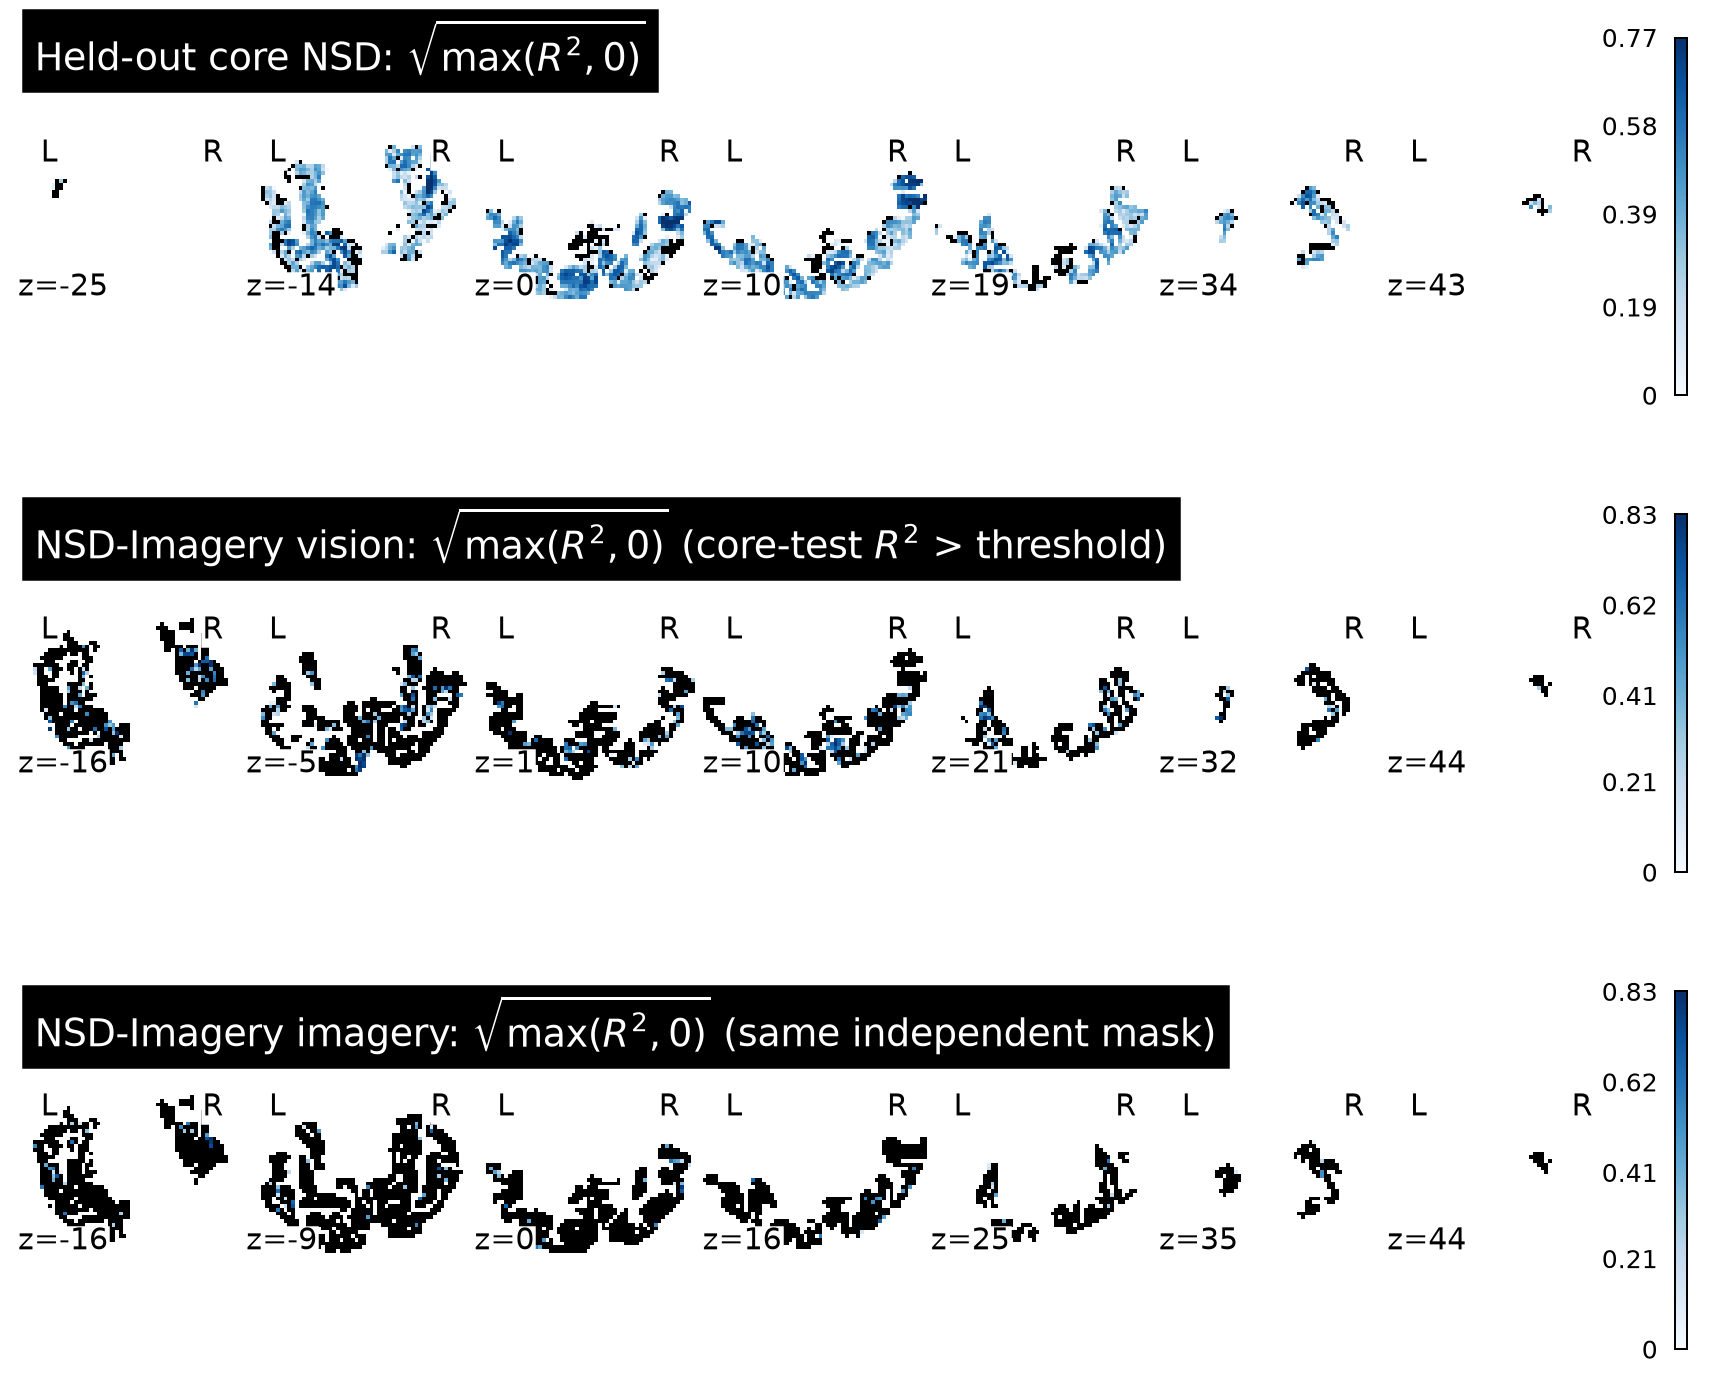

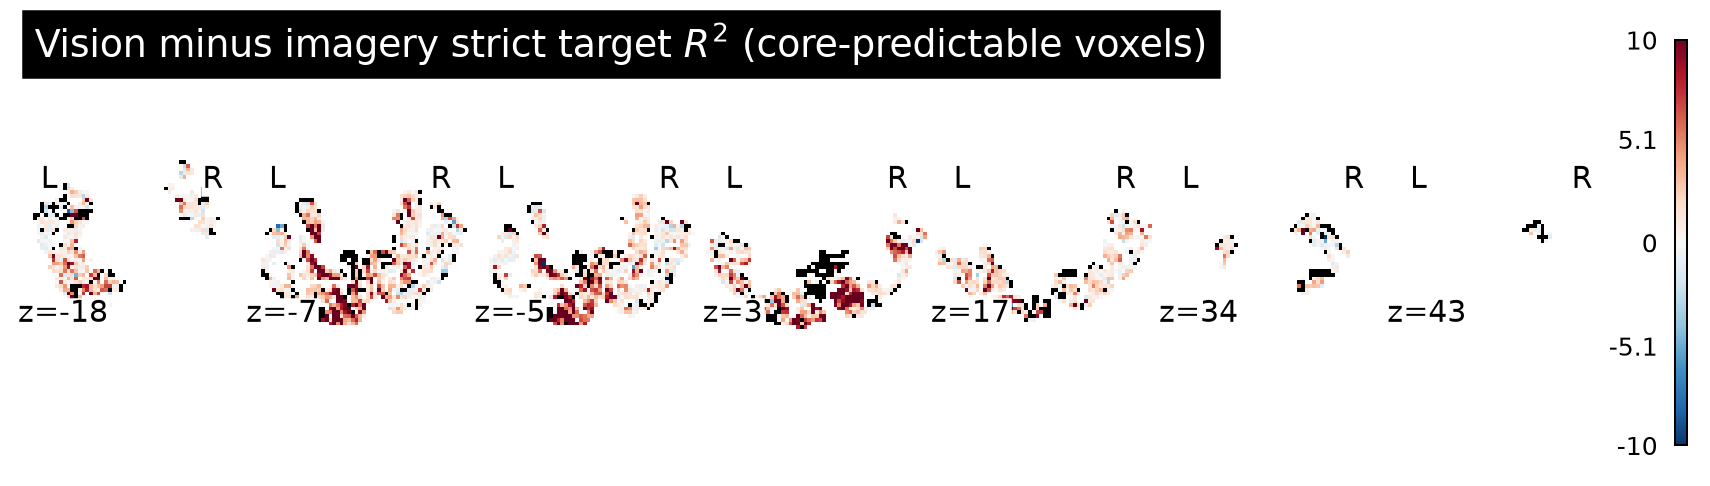

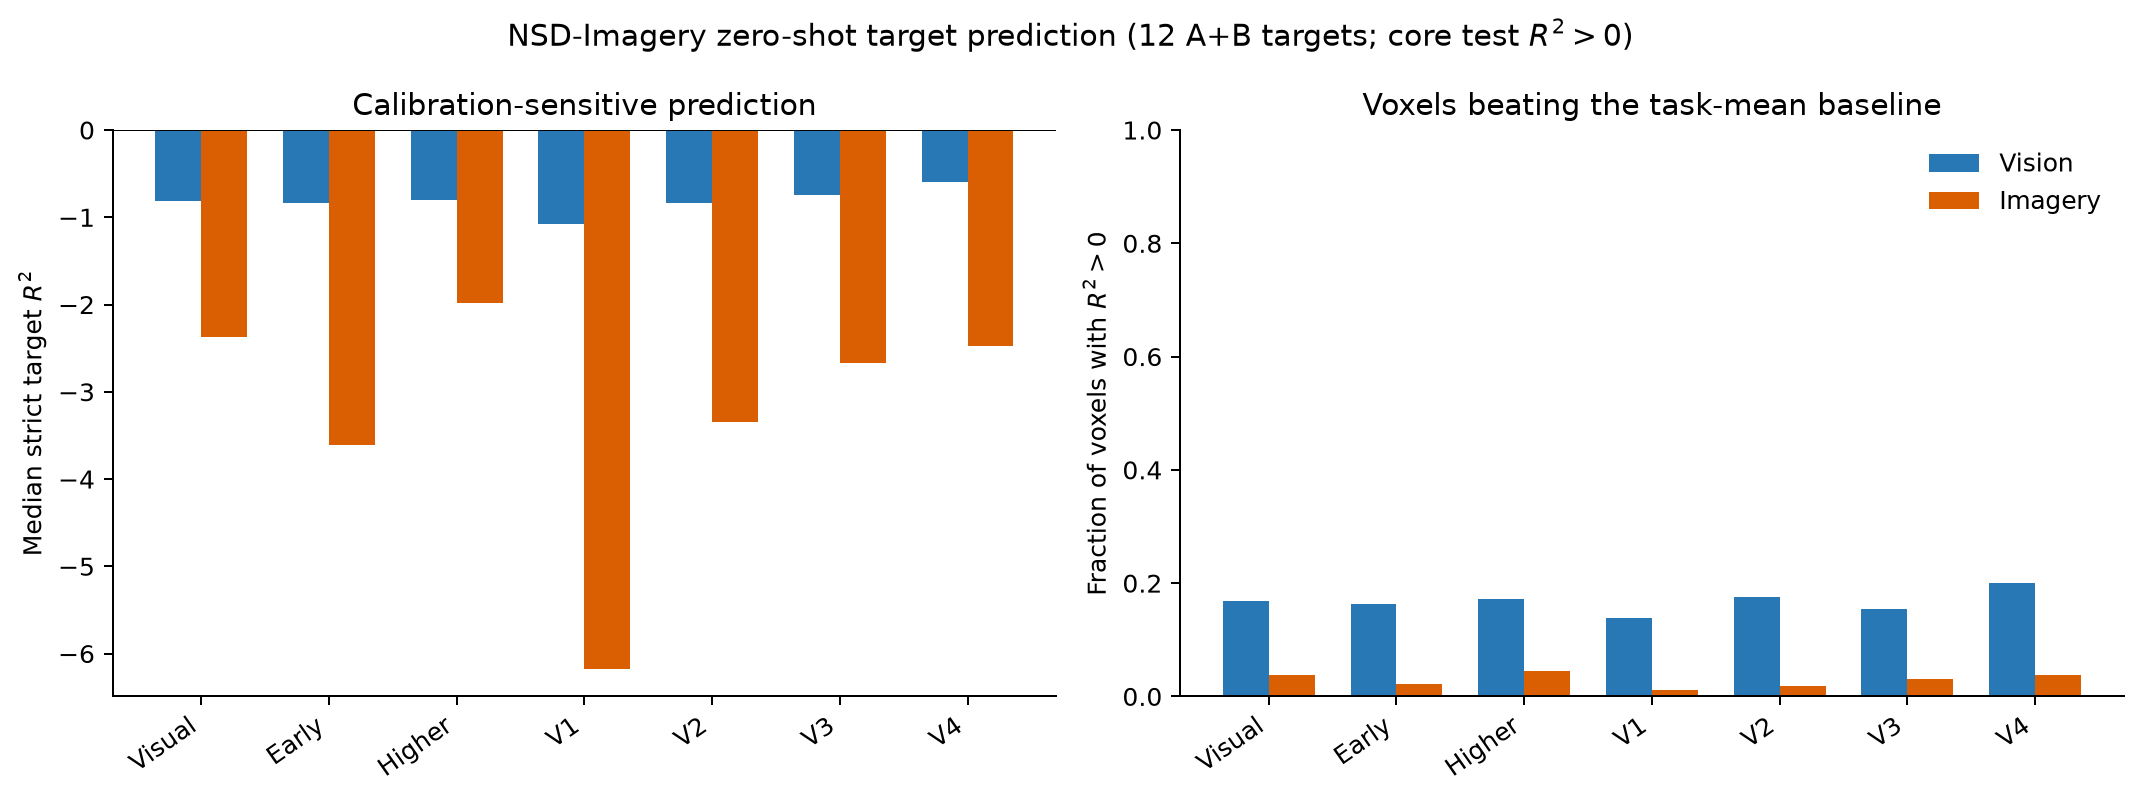

In [9]:
# RUN_R2_MAPS = False
RUN_R2_MAPS = True
r2_output_dir = WORK / 'r2_maps'
map_command = [
    sys.executable, str(REPO_ROOT / 'scripts' / 'plot_encoder_r2_maps.py'),
    '--data-root', str(DATA_ROOT),
    '--subject', str(SUBJECT),
    '--core-voxel-metrics', str(WORK / 'core_test_voxels.csv'),
    '--transfer-voxel-metrics', str(Path(str(evaluation_prefix) + '_voxel_metrics.csv')),
    '--output-dir', str(r2_output_dir),
]
print(' '.join(map_command))
if RUN_R2_MAPS:
    subprocess.run(map_command, check=True)

for figure_name in (
    'encoder_r2_native_slices.png',
    'vision_imagery_r2_difference.png',
    'transfer_r2_roi_summary.png',
):
    figure_path = r2_output_dir / figure_name
    if figure_path.is_file():
        display(Image(filename=str(figure_path)))

## 8. Interpretation and next tier

1. Require positive held-out core-NSD voxel predictivity before interpreting transfer.
2. Treat held-out core-NSD $R^2$ as the primary encoding validation. Compare zero-shot imagery with the model's own vision $R^2$ in the same independently predictable voxels; the claim concerns the size of the drop.
3. Repeat the full frozen analysis with CLIP for an explicitly semantic feature family.
4. Use Notebook 23 for the paper-aligned beta-only diagnostic and reconstruction-scoring scaffold. Subjects remain the uncertainty unit.
5. Only after this baseline works, replace fixed spatial pooling with a learned factorized receptive-field readout and require improvement on the untouched core-NSD test set.